# Mini Equations Experiment Report

This notebook reviews the curated experiments under `examples/mini_eqns/experiments/report` — **13 baseline**, **9 guided**, and **9 step-by-step** runs over the 22-equation trigonometric benchmark. It focuses on the comparisons that matter for the report draft: how each strategy scales with reasoning effort, whether the lighter `mini` and `nano` models pull their weight, and what the new `step_by_step` runs change in the overall picture.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import HTML, SVG, display

for candidate in [Path.cwd(), *Path.cwd().parents]:
    report_dir = candidate / 'examples' / 'mini_eqns' / 'experiments' / 'report'
    if report_dir.exists():
        REPORT_DIR = report_dir
        break
else:
    raise FileNotFoundError('Could not locate examples/mini_eqns/experiments/report from the current working directory.')

if str(REPORT_DIR) not in sys.path:
    sys.path.insert(0, str(REPORT_DIR))

import report_utils as ru

paths = ru.find_report_paths(Path.cwd())
benchmarks = ru.load_benchmarks(paths.benchmark_file)
runs = ru.load_report_runs(paths.report_root)
inventory = ru.build_experiment_inventory(runs)
best_configs = ru.select_best_configs(inventory)
best_baseline_name = str(best_configs.loc[best_configs['family'] == 'baseline', 'experiment_name'].iloc[0])
best_guided_name = str(best_configs.loc[best_configs['family'] == 'guided', 'experiment_name'].iloc[0])
best_step_name = str(best_configs.loc[best_configs['family'] == 'step_by_step', 'experiment_name'].iloc[0])
step_advantage = ru.build_step_advantage_table(runs, benchmarks, best_baseline_name, best_guided_name, best_step_name)

pd.set_option('display.max_colwidth', 120)
display(HTML('''
<style>
.jp-RenderedMarkdown {
  max-width: 920px;
  margin: 0 auto;
  line-height: 1.55;
}
.jp-RenderedMarkdown h1 { font-size: 1.75rem; margin-top: 0.15rem; margin-bottom: 0.55rem; }
.jp-RenderedMarkdown h2 { font-size: 1.22rem; margin-top: 1.35rem; margin-bottom: 0.4rem; }
.jp-RenderedMarkdown h3 { font-size: 1.02rem; margin-top: 0.95rem; margin-bottom: 0.28rem; }
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li { font-size: 0.97rem; }
.table-container, .strategy-wrap { max-width: 920px; margin: 0 auto; }
.report-simple-table, .strategy-matrix {
  border-collapse: collapse;
  width: 100%;
  font-size: 13px;
  margin: 0.35rem 0 0.8rem 0;
}
.report-simple-table th, .report-simple-table td, .strategy-matrix th, .strategy-matrix td {
  border-bottom: 1px solid #e5e7eb;
  padding: 8px 10px;
  text-align: left;
  vertical-align: middle;
}
.report-simple-table th, .strategy-matrix th {
  background: #f8fafc;
  font-weight: 600;
}
.strategy-matrix td.empty {
  color: #94a3b8;
  text-align: center;
}
.matrix-card {
  border-radius: 10px;
  padding: 10px 10px 8px 10px;
  min-width: 108px;
  box-shadow: inset 0 0 0 1px rgba(255,255,255,.45);
}
.matrix-card .solve { font-size: 16px; font-weight: 700; line-height: 1.1; }
.matrix-card .cost { font-size: 12px; margin-top: 4px; }
.matrix-card .label { font-size: 11px; margin-top: 6px; opacity: .82; }
</style>
'''))

## Methodology

All configuration metadata is recovered from `experiment.yaml`, while solved counts and cost come from `results_summary.csv`. The summary matrices below show solved equations out of 22, total run cost, and a short experiment label.

Two legacy baseline runs use reasoning effort `None`: `baseline_experiment_1` and `baseline_experiment_6`. That label is carried explicitly in this report rather than being treated as missing metadata. For the current step-by-step runs, the sketch planner is fixed at `gpt-5.4` with `medium` reasoning effort, so the visible variation comes from the step executor.


## Baseline

A modest amount of forced reasoning helps standard `gpt-5.4`, but pushing harder stops paying off.

- For `gpt-5.4`, `low` and `medium` tie at **19/22**, and `low` is the better choice — **\$1.14** vs **\$1.47**.
- More reasoning is not free: `high` falls to **18/22**, `xhigh` to **17/22** at **\$3.17**, and `None` to **15/22**.
- `gpt-5.4-mini` is dominated (only **10/22** at `low` for **\$2.87**); `gpt-5.4-nano` is the better lightweight option, reaching **17/22** at `high`.


In [2]:
display(HTML(ru.render_strategy_matrix_html(inventory, 'baseline')))

Model,None,low,medium,high,xhigh
GPT-5.4,15 / 22$1.67B1,19 / 22$1.14B2,19 / 22$1.47B3,18 / 22$1.83B4,17 / 22$3.17B5
GPT-5.4 mini,11 / 22$2.95B6,10 / 22$2.87B7,14 / 22$3.39B8,10 / 22$3.96B9,—
GPT-5.4 nano,—,9 / 22$3.06B10,16 / 22$2.73B11,17 / 22$2.68B12,16 / 22$6.57B13


## Guided

Guided search is competitive but does not move the frontier.

- On `gpt-5.4`, guided reaches **18/22**, **19/22**, **19/22** at `low`/`medium`/`high` — essentially tied with baseline.
- The match comes with a **\$0.53–\$0.86** premium per run, depending on effort level.
- Guided does not rescue `gpt-5.4-mini`: solved count stays flat at **12/22** while cost climbs to **\$8.39** at `high`.


In [3]:
display(HTML(ru.render_strategy_matrix_html(inventory, 'guided')))

Model,low,medium,high
GPT-5.4,18 / 22$1.72G14,19 / 22$2.01G15,19 / 22$2.69G16
GPT-5.4 mini,12 / 22$3.09G17,12 / 22$4.57G18,12 / 22$8.39G19
GPT-5.4 nano,11 / 22$3.42G20,14 / 22$3.50G21,16 / 22$5.09G22


## Step-by-Step

The new step-by-step runs are the strongest results in the report and already change the overall conclusion.

- The best run, **step_by_step_experiment_3**, solves **22/22** for **\$1.13** — the only configuration to reach full coverage, and slightly cheaper than the best baseline.
- Across three replicas with `gpt-5.4` / `low`, the step executor consistently lands at **21–22 / 22** for **\$1.13–\$1.34**.
- The lighter executors hold up well: both `gpt-5.4-mini` and `gpt-5.4-nano` at `low` reach **21/22** for around **\$1.55**.


In [4]:
display(HTML(ru.render_step_by_step_matrix_html(inventory)))

Step model,None,low,medium
GPT-5.4,—,"21-22 / 22$1.13-$1.343 runs: S1, S2, S3",—
GPT-5.4 mini,16 / 22$2.20S5,21 / 22$1.57S4,19 / 22$2.07S6
GPT-5.4 nano,12 / 22$2.79S7,21 / 22$1.54S8,21 / 22$2.14S9


## Three-Way Comparison

The strongest current runs are **baseline_experiment_2**, **guided_experiment_15**, and **step_by_step_experiment_3**. This is the headline result: baseline and guided top out at **19/22**, with guided paying a premium, while step-by-step reaches full coverage at essentially the same cost as the best baseline.


In [5]:
leaderboard = inventory.loc[
    inventory['experiment_name'].isin([best_baseline_name, best_guided_name, best_step_name]),
    ['family', 'experiment_name', 'model_name', 'reasoning_effort', 'sketch_model_name', 'sketch_reasoning_effort', 'solved', 'total_cost']
].copy()
leaderboard['strategy'] = leaderboard['family'].map({
    'baseline': 'Baseline',
    'guided': 'Guided',
    'step_by_step': 'Step-by-step',
})
leaderboard['executor'] = leaderboard['model_name'].map(ru.model_label)
leaderboard['executor effort'] = leaderboard['reasoning_effort'].astype(str)
leaderboard['sketch'] = leaderboard.apply(
    lambda row: f"{ru.model_label(str(row['sketch_model_name']))} / {row['sketch_reasoning_effort']}" if row['family'] == 'step_by_step' else '—',
    axis=1,
)
leaderboard = leaderboard[['strategy', 'experiment_name', 'executor', 'executor effort', 'sketch', 'solved', 'total_cost']]
leaderboard = leaderboard.sort_values(['solved', 'total_cost'], ascending=[False, True])
leaderboard = leaderboard.rename(columns={
    'experiment_name': 'experiment',
    'solved': 'solved',
    'total_cost': 'total cost',
})
display(HTML(ru.render_simple_table_html(
    leaderboard,
    formatters={
        'solved': lambda value: f'{int(value)}/22',
        'total cost': ru.precise_money,
    },
)))

strategy,experiment,executor,executor effort,sketch,solved,total cost
Step-by-step,step_by_step_experiment_3,GPT-5.4,low,GPT-5.4 / medium,22/22,$1.1251
Baseline,baseline_experiment_2,GPT-5.4,low,—,19/22,$1.1375
Guided,guided_experiment_15,GPT-5.4,medium,—,19/22,$2.0068


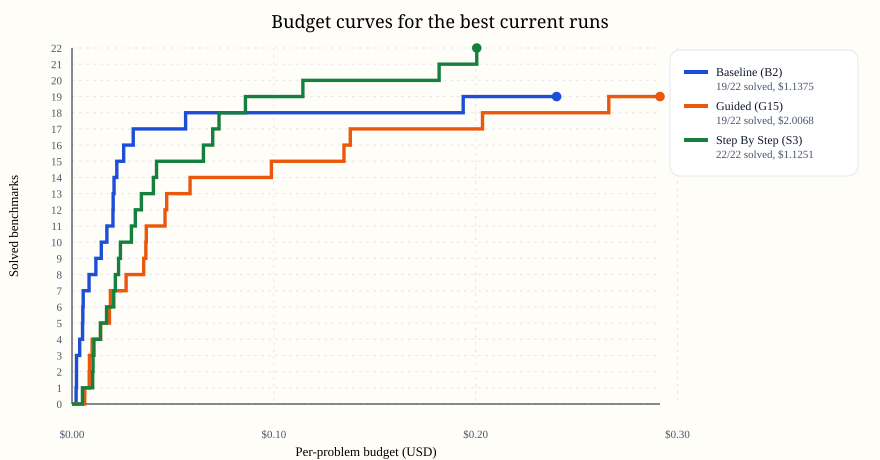

In [6]:
curves = ru.load_budget_curves(paths.report_root, [best_baseline_name, best_guided_name, best_step_name])
display(SVG(ru.render_budget_curves_svg(curves, inventory, title='Budget curves for the best current runs')))

The budget plot makes the comparison easy to read:

- **Step-by-step is the only strategy that reaches 22/22.**
- It does so **without a cost penalty** (\$1.13 vs \$1.14 for the best baseline).
- **Guided matches baseline on solved count but finishes ~\$0.87 higher.**


### Where the extra coverage comes from

The best step-by-step run solves two equations that both best baseline and best guided miss, and gives up nothing in return. The win is a genuine expansion of coverage, not a different trade.


In [7]:
step_only = step_advantage.loc[step_advantage['status'] == 'step_only', ['bench_name', 'equation', 'baseline', 'guided', 'step_by_step']].copy()
step_only = step_only.rename(columns={
    'baseline': 'best baseline',
    'guided': 'best guided',
    'step_by_step': 'best step-by-step',
})
display(HTML(ru.render_simple_table_html(
    step_only,
    formatters={
        'best baseline': lambda value: 'yes' if value else 'no',
        'best guided': lambda value: 'yes' if value else 'no',
        'best step-by-step': lambda value: 'yes' if value else 'no',
    },
)))
print(f'Step regressions against the best baseline/guided runs: {int((step_advantage["status"] == "step_regression").sum())}')

bench_name,equation,best baseline,best guided,best step-by-step
018,cos(x + y)*cos(x - y) = cos(x)**2 - sin(y)**2,no,no,yes
019,sin(x + y)*sin(y - x) = cos(x)**2 - cos(y)**2,no,no,yes


Step regressions against the best baseline/guided runs: 0


## Saturating the Baseline

The headline question for this section: **can the baseline strategy catch up to step-by-step simply by being given more resources?**

To test it, three new runs (`baseline_experiment_saturate_1/2/3`) push the baseline strategy to its limits by raising:

- `max_dollar_budget` — the per-equation spending cap, which controls how many request retries the strategy can afford.
- `max_feedback_cycles` — the maximum number of corrective rounds the model gets when the checker rejects its proof.
- `loop=True` — letting the whole strategy restart on failure, within the budget.

Each saturate level relaxes those limits a bit further. If the baseline gap to step-by-step were just a budget issue, we should see it close as the budget grows.


In [ ]:
saturate_names = ['baseline_experiment_saturate_1', 'baseline_experiment_saturate_2', 'baseline_experiment_saturate_3']

sat_rows = []
for name in saturate_names:
    sub = runs.loc[runs['experiment_name'] == name]
    if sub.empty:
        continue
    sat_rows.append({
        'run': name.replace('baseline_experiment_', ''),
        'max feedback cycles': int(sub['configured_max_feedback_cycles'].iloc[0]),
        'max $/equation': float(sub['configured_budget'].iloc[0]),
        'solved': int(sub['success'].sum()),
        'total cost': float(sub['price'].sum()),
    })

# Reference: best step_by_step run for direct comparison
step_best = inventory.loc[inventory['experiment_name'] == best_step_name].iloc[0]
sat_rows.append({
    'run': 'step_by_step (best)',
    'max feedback cycles': int(step_best['configured_max_feedback_cycles']) if pd.notna(step_best['configured_max_feedback_cycles']) else '—',
    'max $/equation': float(step_best['configured_budget']) if pd.notna(step_best['configured_budget']) else '—',
    'solved': int(step_best['solved']),
    'total cost': float(step_best['total_cost']),
})

saturate_table = pd.DataFrame(sat_rows)
display(HTML(ru.render_simple_table_html(
    saturate_table,
    formatters={
        'solved': lambda v: f'{int(v)}/22',
        'total cost': ru.precise_money,
        'max $/equation': lambda v: f'${v:.2f}' if isinstance(v, (int, float)) else v,
    },
)))


**Reading the table.** Going from `saturate_1` to `saturate_2` raises the per-equation budget from \$0.50 to \$0.75 and the feedback cycles from 30 to 40. That extra budget rescues exactly **one** more equation (from **19/22** to **20/22**) at the cost of an extra **~\$0.74** of total spend. `saturate_3` keeps the higher budget and runs again with `max_feedback_cycles=20`, mostly to confirm the trend on a fresh seed.

**The verdict.** Even fully saturated, baseline tops out at **20/22** while spending roughly **2.5×** what the best step-by-step run spends to reach **22/22**. The two equations that survive every saturation level (**018** and **019**, both *derived product identities*) are the same ones step-by-step solves at lower cost. This is the strongest evidence in the report that the bottleneck is **strategy, not budget**: handing the baseline more retries does not buy structurally new behavior, it just lets it grind a little longer on proofs that were already going to succeed.


## Common Failure Patterns by Model

The artifacts do not record free-form error labels, so failures are grouped by the identity family of the missed benchmark.

- **`gpt-5.4`** is narrow: its main weakness is *derived product identities* (**18/22**, **81.8%**).
- **`gpt-5.4-mini`** is broad: same weakness even sharper (**19/20**, **95%**), plus higher-order sine rewrites and periodicity.
- **`gpt-5.4-nano`** sits between the two — same top-two miss families, slightly more controlled overall.

The persistent weak spot across all three models is the more derived identities built from multiple transformations, especially benchmarks **018** and **019**.


In [8]:
BENCHMARK_GROUPS = {
    '001': 'phase shifts', '002': 'phase shifts', '003': 'phase shifts', '004': 'phase shifts',
    '005': 'special angles', '006': 'special angles', '007': 'special angles',
    '008': 'periodicity', '009': 'periodicity',
    '010': 'pythagorean',
    '011': 'double-angle / half-angle', '012': 'sum-product transforms', '013': 'sum-product transforms',
    '014': 'double-angle / half-angle', '015': 'double-angle / half-angle', '016': 'double-angle / half-angle', '017': 'double-angle / half-angle',
    '018': 'derived product identities', '019': 'derived product identities',
    '020': 'higher-order sine rewrites', '021': 'higher-order sine rewrites', '022': 'higher-order sine rewrites',
}

model_runs = runs.copy()
model_runs['analysis model'] = model_runs['model_name'].astype(str)
step_mask = model_runs['family'] == 'step_by_step'
model_runs.loc[step_mask, 'analysis model'] = model_runs.loc[step_mask, 'step_model_name'].astype(str)
model_runs['identity family'] = model_runs['bench_name'].map(BENCHMARK_GROUPS)
model_runs['failed'] = ~model_runs['success']
summary = (
    model_runs.groupby(['analysis model', 'identity family'], dropna=False)
    .agg(failures=('failed', 'sum'), total=('failed', 'size'))
    .reset_index()
)
summary['failure rate'] = summary['failures'] / summary['total']
summary = summary.sort_values(['analysis model', 'failure rate', 'failures', 'identity family'], ascending=[True, False, False, True])
ranked = summary.groupby('analysis model').head(3).copy()
ranked['family'] = ranked['identity family']
ranked['evidence'] = ranked.apply(lambda row: f"{int(row['failures'])}/{int(row['total'])} ({row['failure rate']:.1%})", axis=1)
ranked = ranked[['analysis model', 'family', 'evidence']].rename(columns={'analysis model': 'model'})
display(HTML(ru.render_simple_table_html(ranked)))

model,family,evidence
gpt-5.4,derived product identities,18/22 (81.8%)
gpt-5.4,higher-order sine rewrites,12/33 (36.4%)
gpt-5.4,double-angle / half-angle,4/55 (7.3%)
gpt-5.4-mini,derived product identities,19/20 (95.0%)
gpt-5.4-mini,higher-order sine rewrites,25/30 (83.3%)
gpt-5.4-mini,periodicity,12/20 (60.0%)
gpt-5.4-nano,derived product identities,18/20 (90.0%)
gpt-5.4-nano,higher-order sine rewrites,23/30 (76.7%)
gpt-5.4-nano,periodicity,6/20 (30.0%)


## Why Step-by-Step Works

The previous section shows *that* step-by-step beats a saturated baseline. This section explains *why*. The goal is to make the design legible without forcing the reader to open `step_by_step.py`.

### A planner / executor split

Step-by-step is built as two phases that talk to each other through a verifier:

- **Phase 1 — Sketch.** A *large* model (default `gpt-5.4` at `high` reasoning) is called **once** to produce a verifier-compatible **proof sketch**.
- **Phase 2 — Steps.** A *small* model (default `gpt-5.4-mini` at `low` reasoning) is called **many times**, once per proof step, with the validated sketch in its context.
- **The checker** runs between every step and is the ground truth that keeps both models honest.

This is the classical AI planner/executor split: the expensive component decides *what* to do, the cheap component decides *how* to write it down, and a deterministic verifier rejects anything that does not type-check. The cost intuition is the key one: one expensive sketch call amortizes over 5–15 cheap step calls, so the total looks much more like "many small calls" than "one big call".

### The role of the first draft (sketch)

A sketch is a numbered list, where each line names exactly one allowed move and the local goal it produces. A toy example:

```
1. rule:sin_neg → -sin(x)
2. step → -sin(x)
3. trans:[1,2]
```

That tiny grammar is doing four jobs at once:

1. **It gives the executor a target.** The step model never has to invent strategy mid-proof — it only has to translate the next sketch line into a verifier-accepted YAML step. Most local errors collapse to "produce the move named on line *k*".
2. **It collapses the search.** An open-ended proof search becomes a sequence of small, locally checkable subproblems. A wrong step is caught immediately and only that single step is retried; the rest of the proof is preserved.
3. **It is a budget multiplier.** Planning is the expensive part of a proof. Doing it once, well, is much cheaper than asking a weak model to re-plan implicitly on every retry of a one-shot attempt.
4. **It is a contract.** Because the sketch is machine-readable, the system can match step *k* of the YAML proof against line *k* of the plan. Errors become local and traceable instead of global and mysterious.

### Why the draft is *not* in natural language

This is the design choice that does the most work, and it is the easiest to get wrong.

If the sketch were free-form text, an LLM would happily write things like *"now apply the difference of squares"* or *"use the half-angle identity here"*. Both sentences sound correct. Both reference rules that **do not exist** in the verifier's `TRIG_RULES` table. A natural-language sketch built on those rules looks fine to a human reader, but the downstream step model has only two options when it tries to execute it: fake the rule (which the checker rejects) or get stuck (which burns retries). Either way, the entire proof attempt is poisoned from the planning step onwards.

A natural-language sketch is also a contract you cannot enforce. There is no way for the verifier to ask *"does step 4 of your YAML proof match line 4 of your plan?"* because the plan is prose. Errors only surface at the very end of the proof, and when they do, they cannot be localized.

A strict, machine-readable sketch turns *"is this plan executable?"* into a syntactic question. You can answer that question **before** generating a single proof step — and that is exactly what `_validate_sketch` does in `step_by_step.py`.

### Why the parsing is so specific

The sketch validator checks several things, and each check exists to prevent a real failure mode that was observed in practice:

- **Allowed-move tokens (`rule:`, `sym`, `step`, `trans`).** Every sketch line must contain one of these. This forces the planner to commit to one of the verifier's primitives per line and structurally rejects free-form prose.
- **Banned macro phrases** (`difference of squares`, `half-angle`, `product-to-sum`, `sum-to-product`). These are exactly the macros LLMs love to invoke and the checker does not implement. Catching them in the sketch means the planner is told to fix its plan *once*, instead of letting the step model hit the same wall on a dozen step-level retries.
- **Numbered lines** (`1.`, `2.`, …). Every sketch line gets a stable ID so step-level feedback can say *"your step 4 does not match plan line 4"* instead of just *"this is wrong"*.
- **Single-step `trans` rejection.** A `trans:[i]` with only one element is a no-op, so the validator requires `trans` lines to chain at least two prior steps. This forces the planner to actually decompose its sub-lemmas instead of pretending it has.
- **Overlapping `vars:` substitutions.** This is the subtlest one. A substitution like `{x:"y", y:"-y"}` looks innocuous, but SymPy applies substitutions sequentially: `x` first becomes `y`, and then that fresh `y` is rewritten to `-y`, corrupting the result. The validator detects the overlap and emits a targeted hint to rewrite it as `{x:"-y", y:"y"}`. This is the kind of bug a one-shot baseline would silently ship — nothing in the YAML output looks wrong, but the proof is mathematically invalid.

Crucially, every rejection is returned as a structured `dp.Error` with a *specific* fix instruction. The planner does not get a vague "try again"; it gets "you cited `half-angle` on line 3, derive it from `cos2x` instead". That is the difference between feedback that converges and feedback that thrashes.

### Phase 2: one verified step at a time

Once the sketch is validated, Phase 2 is deliberately small-grained:

- **The search tree branches at the *step* level, not the *proof* level.** A failed step costs one small-model call. A failed proof in the baseline costs an entire conversation, including all the work that *was* correct.
- **Each step has a tight, local target.** The current sub-goal is computed from the sketch and shown explicitly in the prompt, so the step model knows exactly what expression it must produce.
- **Feedback is also local.** When the checker rejects a step, the error message is about that single line, which the small model can usually fix in one retry.
- **Sub-lemma support via `trans:[ids]`** lets the planner introduce intermediate goals (e.g. prove an auxiliary identity, then reuse it). This is exactly the structural move that makes the hardest benchmarks (**018**, **019**) tractable.

### Why this beats a saturated baseline

Tying it back to the previous section: baseline saturation throws retries at a one-shot proof. Each retry is **uncoordinated** — the model has no memory of *which* part of the previous attempt was right, only that the whole thing failed. So extra budget mostly buys lucky resamples.

Step-by-step instead spends its budget on **structure**: one good plan, many cheap and verified executions. The saturate runs are direct empirical proof that the missing ingredient is structure, not budget — equations 018 and 019 stay unsolved at every saturation level, but fall to step-by-step at lower total cost.

In one sentence: **22/22 at \$1.13 is what you get when the verifier participates in the search, not just at the end of it.**
